# Paid advertising uplift: who is worth bidding on

An advertiser holds one budget and bids on a population. Some users convert
because of the ad. Others convert anyway, and the budget pays for a sale that
was coming.

A response model finds who converts. An uplift model finds who converts
**because of** the ad. This notebook separates the two and ends with a
bidding rule.

The order is CRISP-DM. The data is CRITEO-UPLIFTv2, from a randomised trial
in real-time bidding, which is the mechanism behind Meta Ads and Google Ads.

## Phase 0. Setup

Fixed seed, pinned imports, and one helper that caches the data sample.

In [1]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from sklift.models import SoloModel, TwoModels
from sklift.metrics import qini_auc_score, uplift_at_k

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

FEATURES = [f"f{i}" for i in range(12)]
DATA_URL = ("https://huggingface.co/datasets/criteo/criteo-uplift/"
            "resolve/main/criteo-research-uplift-v2.1.csv.gz")
RAW = "criteo-uplift-v2.1.csv.gz"
SAMPLE = "criteo10.parquet"
META = "criteo10.meta.json"
import sys
print("python", sys.version.split()[0], "| lightgbm", lgb.__version__,
      "| pandas", pd.__version__, "| numpy", np.__version__, "| sklearn", __import__("sklearn").__version__)

python 3.12.10 | lightgbm 4.7.0 | pandas 3.0.5 | numpy 2.5.2 | sklearn 1.9.0


### The loader

The source file is 297 MB compressed and 3.2 GB open. The notebook works on a
deterministic 10% sample, drawn one chunk at a time so the memory stays flat.
The sample is cached, so a second run reads the parquet file.

In [2]:
def load_sample(frac=0.10, seed=SEED):
    if os.path.exists(SAMPLE) and os.path.exists(META):
        return pd.read_parquet(SAMPLE)
    if not os.path.exists(RAW):
        import urllib.request
        print("downloading 297 MB ...")
        urllib.request.urlretrieve(DATA_URL, RAW)
    dtype = {f"f{i}": "float32" for i in range(12)}
    dtype.update({c: "int8" for c in ["treatment", "conversion", "visit", "exposure"]})
    parts, rows = [], 0
    for i, chunk in enumerate(pd.read_csv(RAW, dtype=dtype, chunksize=1_000_000)):
        rows += len(chunk)
        parts.append(chunk.sample(frac=frac, random_state=seed + i))
    out = pd.concat(parts, ignore_index=True)
    out.to_parquet(SAMPLE, index=False)
    with open(META, "w") as fh:
        json.dump({"source_rows": rows, "sample_rows": len(out), "fraction": frac}, fh)
    return out

raw = load_sample()
meta = json.load(open(META))
print(f"source rows  {meta['source_rows']:,}")
print(f"sample rows  {meta['sample_rows']:,}  ({meta['fraction']:.0%})")
print(f"columns      {raw.shape[1]}")
raw.head(3)

source rows  13,979,592
sample rows  1,397,959  (10%)
columns      16


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,22.296614,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
1,12.674733,10.679513,8.214383,1.614662,10.280525,3.013064,-5.987667,5.917329,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,21.566525,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


## Phase 1. Business understanding

**The decision.** An advertiser sets a bidding list. Every user on it costs
money at auction. Every user off it sees nothing.

**The question.** Which users convert because of the ad?

The treated group converts more. That fact mixes two things: the ad working,
and the treated group being different. Uplift is what is left after the control
group is subtracted.

**The SLI.** The Qini coefficient of the model, measured on users held out of
training. Qini measures how much better the ranking is than random targeting.

**The SLO.** Two conditions, both required in every fold:

1. Qini above zero.
2. The top decile carries more uplift than the population average.

Both are written before the first model runs, so no result sets its own bar.

## Phase 2. Data understanding

Premise: the data arrives claiming to be a randomised trial. Seven rules test
that, and the balance rules are the ones that license every causal claim below.

In [3]:
rates = raw.groupby("treatment").agg(
    users=("visit", "size"),
    visit_rate=("visit", "mean"),
    conversion_rate=("conversion", "mean"),
    exposure_rate=("exposure", "mean")).round(5)
rates.index = ["control", "treated"]
print(rates.to_string())
print(f"\nraw difference in visit rate:      "
      f"{(rates.visit_rate['treated'] - rates.visit_rate['control']) * 100:.3f}pp")
print(f"raw difference in conversion rate: "
      f"{(rates.conversion_rate['treated'] - rates.conversion_rate['control']) * 100:.3f}pp")

           users  visit_rate  conversion_rate  exposure_rate
control   209938     0.03828          0.00201        0.00000
treated  1188021     0.04845          0.00314        0.03608

raw difference in visit rate:      1.017pp
raw difference in conversion rate: 0.113pp


The control group has an exposure rate of zero, by construction. A user in the
control group is held out of the auction, so nothing can win it.

`exposure` is therefore **not** randomised: winning an auction depends on the
user and on the competition. Every model below is trained on `treatment`.

In [4]:
treated, control = raw[raw.treatment == 1], raw[raw.treatment == 0]
smd = pd.DataFrame({
    "mean_treated": treated[FEATURES].mean(),
    "mean_control": control[FEATURES].mean(),
})
smd["std_mean_diff"] = ((treated[FEATURES].mean() - control[FEATURES].mean())
    / np.sqrt((treated[FEATURES].var() + control[FEATURES].var()) / 2))
print(smd.round(4).to_string())
print(f"\nlargest absolute standardised difference: {smd.std_mean_diff.abs().max():.4f}")

     mean_treated  mean_control  std_mean_diff
f0      19.609100       19.6485        -0.0073
f1      10.070300       10.0677         0.0272
f2       8.446500        8.4487        -0.0076
f3       4.167200        4.2318        -0.0497
f4      10.339800       10.3375         0.0068
f5       4.026500        4.0392        -0.0304
f6      -4.184700       -4.0054        -0.0396
f7       5.104900        5.0824         0.0189
f8       3.933300        3.9345        -0.0201
f9      16.055599       15.8894         0.0240
f10      5.333900        5.3328         0.0063
f11     -0.171000       -0.1709        -0.0061

largest absolute standardised difference: 0.0497


Every standardised difference sits under 0.05. The convention is that anything
under 0.10 is balance.

In [5]:
check = raw.sample(200_000, random_state=SEED)
propensity = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores = cross_val_predict(propensity, check[FEATURES], check.treatment,
                           cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                           method="predict_proba")[:, 1]
auc = roc_auc_score(check.treatment, scores)
print(f"propensity AUC: {auc:.4f}")
print("A value near 0.50 means the features cannot predict who was treated.")

propensity AUC: 0.5114
A value near 0.50 means the features cannot predict who was treated.


In [6]:
profiles = raw.duplicated(subset=FEATURES, keep=False)
repeated = raw[profiles].groupby(FEATURES)[["visit", "treatment"]].nunique()
print(f"identical rows, every column          {raw.duplicated().sum():,}")
print(f"identical rows, features only         {raw.duplicated(subset=FEATURES).sum():,}")
print(f"profiles that appear more than once   {len(repeated):,}")
print(f"of those, with a different outcome    {(repeated.visit > 1).sum():,}")
print(f"of those, in both groups              {(repeated.treatment > 1).sum():,}")

identical rows, every column          22,177


identical rows, features only         29,941
profiles that appear more than once   28,424
of those, with a different outcome    126
of those, in both groups              7,549


In [7]:
quality = pd.DataFrame([
    ("No null in any column", int(raw.isna().sum().sum())),
    ("No duplicate row", int(raw.duplicated().sum())),
    ("Treatment is binary", int((~raw.treatment.isin([0, 1])).sum())),
    ("Control is never exposed", int(((raw.treatment == 0) & (raw.exposure == 1)).sum())),
    ("Conversion implies visit", int(((raw.conversion == 1) & (raw.visit == 0)).sum())),
    ("Balance under 0.10 SMD", int((smd.std_mean_diff.abs() >= 0.10).sum())),
    ("Propensity AUC under 0.55", int(auc >= 0.55)),
], columns=["rule", "offenders"])
quality["verdict"] = np.where(quality.offenders == 0, "pass", "FAIL")
print(quality.to_string(index=False))

                     rule  offenders verdict
    No null in any column          0    pass
         No duplicate row      22177    FAIL
      Treatment is binary          0    pass
 Control is never exposed          0    pass
 Conversion implies visit          0    pass
   Balance under 0.10 SMD          0    pass
Propensity AUC under 0.55          0    pass


Six rules pass and one fails.

The failure is the duplicates. The features are dense and anonymous, so a
profile that repeats is the same twelve numbers arriving twice.

Thousands of those profiles sit in both groups. The same twelve numbers then
land in the training fold and in the fold that scores it, so a tree can
memorise instead of generalise.

Rößler and Schoder remove them from this data set for the same reason.

**Answer.** The randomisation holds, so the causal claim is licensed. The
duplicates leave in phase 3. `exposure` stays out of every model.

## Phase 3. Data preparation

Premise: a fold that holds no positive row cannot measure anything.

Three layers, as in the SQL projects: landing, conformed, model ready.

In [8]:
clean = raw.drop_duplicates().reset_index(drop=True)
print(f"landing   {len(raw):,} rows")
print(f"conformed {len(clean):,} rows  ({len(raw) - len(clean):,} duplicates removed, "
      f"{100 * (len(raw) - len(clean)) / len(raw):.2f}%)")

X = clean[FEATURES]
y_visit = clean["visit"].to_numpy()
y_conv = clean["conversion"].to_numpy()
treat = clean["treatment"].to_numpy()

# One label per fold, so a fold holds the same mix of group and outcome.
fold_label = np.char.add(treat.astype(str), y_visit.astype(str))
print("\nstratification classes:")
print(pd.Series(fold_label).value_counts().rename("rows").to_string())

landing   1,397,959 rows
conformed 1,375,782 rows  (22,177 duplicates removed, 1.59%)



stratification classes:
10    1108968
00     201212
11      57565
01       8037


The counts above are the reason the models are trained on `visit`. Uplift is a
difference between two groups, so the binding number is the smallest cell.

For visits that cell holds 8,037 rows, about 1,600 a fold.

Conversion is a different matter. The whole sample carries 4,157 conversions
and only 423 of them are in the control group, which is 85 a fold. A ranking
cannot be measured against 85 rows.

So the models rank on visits, and phase 6 asks the question that decides the
budget: does that ranking also deliver conversions?

Stratification at this size is insurance rather than rescue. A random split of
1.4 million rows would land close on its own.

It costs nothing, and it removes the fold-to-fold variation that would
otherwise be read as model variation.

## Phase 4. Modelling

Premise: the sophisticated model wins.

Three models, three families. The first is the baseline. Anything that cannot
beat it is not worth shipping.

| Model | What it does |
| --- | --- |
| Logistic regression, treatment dummy | One linear model, with treatment and its interactions as features |
| LightGBM, treatment dummy | The same shape, with a gradient boosted tree |
| Two-model LightGBM | One model per group. The difference between them is the uplift |

In [9]:
GRID = [
    dict(num_leaves=31, min_child_samples=200),
    dict(num_leaves=63, min_child_samples=200),
    dict(num_leaves=63, min_child_samples=1000),
    dict(num_leaves=127, min_child_samples=1000),
]

def lgbm(params):
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, subsample=0.8,
                              subsample_freq=1, colsample_bytree=0.8, n_jobs=-1,
                              verbose=-1, random_state=SEED, **params)

def inner_search(Xi, yi, ti, seed):
    """Pick tree parameters inside the training fold only."""
    label = np.char.add(ti.astype(str), yi.astype(str))
    idx = np.random.RandomState(seed).choice(len(Xi), min(300_000, len(Xi)), replace=False)
    Xi, yi, ti, label = Xi.iloc[idx], yi[idx], ti[idx], label[idx]
    best_score, best_params = -np.inf, None
    for params in GRID:
        scores = []
        for a, b in StratifiedKFold(3, shuffle=True, random_state=seed).split(Xi, label):
            model = SoloModel(lgbm(params), method="dummy").fit(Xi.iloc[a], yi[a], ti[a])
            scores.append(qini_auc_score(yi[b], model.predict(Xi.iloc[b]), ti[b]))
        score = float(np.mean(scores))
        if score > best_score:
            best_score, best_params = score, params
    return best_params, best_score

The search runs **inside** the training fold, on its own 3-fold split. A search
that reads the fold it reports on inflates the number it reports.

In [10]:
NAMES = ["Logistic, treatment dummy", "LightGBM, treatment dummy", "Two-model LightGBM"]
outer = StratifiedKFold(5, shuffle=True, random_state=SEED)
results, chosen = [], []
oof = {name: np.zeros(len(X)) for name in NAMES}   # every row scored by a model that never saw it
oof_fold = np.zeros(len(X), dtype=int)
start = time.time()

for k, (train, test) in enumerate(outer.split(X, fold_label), 1):
    params, inner_qini = inner_search(X.iloc[train], y_visit[train], treat[train], seed=100 + k)
    chosen.append({"fold": k, **params, "inner_qini": round(inner_qini, 4)})
    oof_fold[test] = k

    models = dict(zip(NAMES, [
        SoloModel(make_pipeline(StandardScaler(), LogisticRegression(max_iter=400)), method="dummy"),
        SoloModel(lgbm(params), method="dummy"),
        TwoModels(lgbm(params), lgbm(params), method="vanilla")]))
    for name, model in models.items():
        model.fit(X.iloc[train], y_visit[train], treat[train])
        uplift = model.predict(X.iloc[test])
        oof[name][test] = uplift
        results.append({
            "model": name, "fold": k,
            "qini": qini_auc_score(y_visit[test], uplift, treat[test]),
            "uplift_top10": uplift_at_k(y_visit[test], uplift, treat[test],
                                        strategy="overall", k=0.1)})
    print(f"fold {k} done, {time.time() - start:.0f}s, params {params}", flush=True)

folds = pd.DataFrame(results)
print()
print(pd.DataFrame(chosen).to_string(index=False))

fold 1 done, 128s, params {'num_leaves': 127, 'min_child_samples': 1000}


fold 2 done, 243s, params {'num_leaves': 63, 'min_child_samples': 1000}


fold 3 done, 341s, params {'num_leaves': 31, 'min_child_samples': 200}


fold 4 done, 473s, params {'num_leaves': 127, 'min_child_samples': 1000}


fold 5 done, 578s, params {'num_leaves': 63, 'min_child_samples': 200}



 fold  num_leaves  min_child_samples  inner_qini
    1         127               1000      0.0812
    2          63               1000      0.0860
    3          31                200      0.0889
    4         127               1000      0.0805
    5          63                200      0.0731


In [11]:
summary = (folds.groupby("model")
           .agg(mean_qini=("qini", "mean"), std_qini=("qini", "std"),
                worst_fold=("qini", "min"), mean_uplift_top10=("uplift_top10", "mean"))
           .sort_values("mean_qini", ascending=False).round(4))
print(summary.to_string())

                           mean_qini  std_qini  worst_fold  mean_uplift_top10
model                                                                        
LightGBM, treatment dummy     0.0847    0.0050      0.0761             0.0588
Logistic, treatment dummy     0.0765    0.0032      0.0710             0.0506
Two-model LightGBM            0.0717    0.0046      0.0661             0.0595


**Answer.** The premise fails.

The two-model approach is the one the field reaches for, and it comes last.

It fits two classifiers and subtracts them. Each one spends its capacity on
predicting visits, and the small difference between them carries the error of
both.

The single LightGBM with a treatment dummy wins on the mean and on the worst
fold. The gap over logistic regression is about one standard deviation, so the
tree earns its place, and it does not run away with the result.

The spread across folds is what a single split cannot show. Fold 5 and fold 1
differ by more than the gap between the first and second model.

## Phase 5. Evaluation

Two parts. The A/B test asks whether the ad worked. The Qini curve asks whether
the model ranks users better than chance.

In [12]:
def two_proportion_test(y, t, label, alpha=0.05, power=0.80):
    n1, n0 = int(t.sum()), int((1 - t).sum())
    p1, p0 = y[t == 1].mean(), y[t == 0].mean()
    diff = p1 - p0
    pooled = (y[t == 1].sum() + y[t == 0].sum()) / (n1 + n0)
    se_null = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n0))
    z = diff / se_null
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    z_a, z_b = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
    mde = (z_a + z_b) * np.sqrt(p0 * (1 - p0) * (1 / n1 + 1 / n0))
    return {"metric": label, "treated_pct": round(p1 * 100, 3), "control_pct": round(p0 * 100, 3),
            "lift_pp": round(diff * 100, 3), "relative_pct": round(100 * diff / p0, 1),
            "ci_low_pp": round((diff - z_a * se) * 100, 3),
            "ci_high_pp": round((diff + z_a * se) * 100, 3), "z": round(z, 1),
            "p_value": f"{p_value:.2g}" if p_value > 1e-16 else "<1e-16",
            "mde_pp": round(mde * 100, 3)}

ab = pd.DataFrame([two_proportion_test(y_visit, treat, "visit"),
                   two_proportion_test(y_conv, treat, "conversion")])
print(ab.to_string(index=False))

    metric  treated_pct  control_pct  lift_pp  relative_pct  ci_low_pp  ci_high_pp    z p_value  mde_pp
     visit        4.935        3.841    1.094          28.5      1.003       1.185 21.6  <1e-16   0.128
conversion        0.320        0.202    0.118          58.3      0.096       0.140  9.1  <1e-16   0.030


**Hypothesis.** The ad has no effect. The visit rate of the treated group equals
the visit rate of the control group.

Both metrics reject it. The confidence interval on visits runs from 1.00 to
1.19 percentage points, and the effect is eight times the minimum this sample
can detect.

The p-value states how surprising this data would be if the ad did nothing. It
does not state the probability that the ad works.

It also says nothing about the size of the effect. The confidence interval
carries the size.

The randomisation from phase 2 is what makes this a causal statement rather than
a correlation.

In [13]:
def qini_points(y, uplift, t):
    """The Qini curve, drawn from the definition rather than called from a library."""
    order = np.argsort(-uplift, kind="mergesort")
    y, t = y[order], t[order]
    treated_y, control_y = np.cumsum(y * t), np.cumsum(y * (1 - t))
    n_treated, n_control = np.cumsum(t), np.cumsum(1 - t)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(n_control > 0, n_treated / np.maximum(n_control, 1), 0)
    curve = treated_y - control_y * ratio
    x = np.arange(1, len(y) + 1) / len(y)
    return np.insert(x, 0, 0), np.insert(curve, 0, 0)

In [14]:
_check = np.random.RandomState(SEED).choice(len(X), 200_000, replace=False)
_x, _curve = qini_points(y_visit[_check], oof["LightGBM, treatment dummy"][_check], treat[_check])
_area = np.trapezoid(_curve, _x) - _curve[-1] / 2
_random = np.trapezoid(_x * _curve[-1], _x)
print(f"hand-drawn Qini, normalised: {_area / _random:.4f}")
print(f"sklift qini_auc_score:       "
      f"{qini_auc_score(y_visit[_check], oof['LightGBM, treatment dummy'][_check], treat[_check]):.4f}")

hand-drawn Qini, normalised: 0.6509


sklift qini_auc_score:       0.0828


The two agree, so the curve below is the metric and not a picture beside it.

In [15]:
winner = summary.index[0]
oof_uplift = oof[winner]
print(f"carried forward: {winner}")
print(f"scores come from phase 4, so nothing is refitted and nothing is scored by a model that saw it")

carried forward: LightGBM, treatment dummy
scores come from phase 4, so nothing is refitted and nothing is scored by a model that saw it


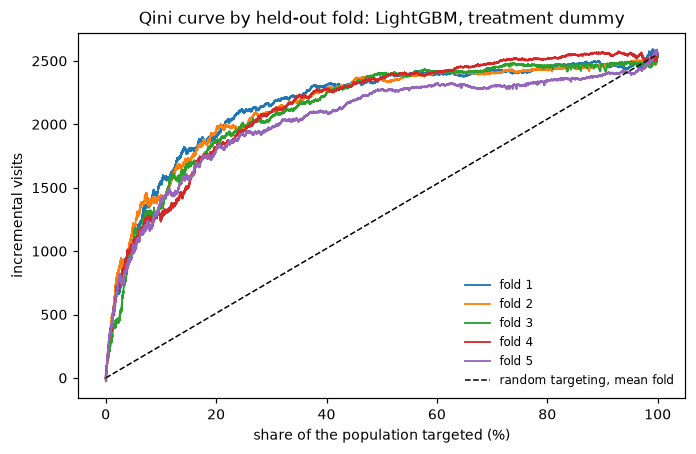

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ends = []
for k in range(1, 6):
    m = oof_fold == k
    x, curve = qini_points(y_visit[m], oof_uplift[m], treat[m])
    ends.append(curve[-1])
    ax.plot(x * 100, curve, lw=1.2, label=f"fold {k}")
ax.plot([0, 100], [0, np.mean(ends)], color="black", ls="--", lw=1,
        label="random targeting, mean fold")
ax.set_xlabel("share of the population targeted (%)")
ax.set_ylabel("incremental visits")
ax.set_title(f"Qini curve by held-out fold: {winner}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [17]:
verdict = []
overall = y_visit[treat == 1].mean() - y_visit[treat == 0].mean()
for k in range(1, 6):
    m = oof_fold == k
    q = qini_auc_score(y_visit[m], oof_uplift[m], treat[m])
    top = np.argsort(-oof_uplift[m])[: int(m.sum() * 0.1)]
    yy, tt = y_visit[m][top], treat[m][top]
    top_uplift = yy[tt == 1].mean() - yy[tt == 0].mean()
    verdict.append({"fold": k, "qini": round(q, 4),
                    "uplift_top10_pp": round(top_uplift * 100, 3),
                    "uplift_overall_pp": round(overall * 100, 3),
                    "slo_verdict": "pass" if (q > 0 and top_uplift > overall) else "FAIL"})
slo = pd.DataFrame(verdict)
print(slo.to_string(index=False))
print(f"\nSLO met in {(slo.slo_verdict == 'pass').sum()} of 5 folds")

 fold   qini  uplift_top10_pp  uplift_overall_pp slo_verdict
    1 0.0887            6.533              1.094        pass
    2 0.0872            6.039              1.094        pass
    3 0.0850            5.678              1.094        pass
    4 0.0866            5.170              1.094        pass
    5 0.0761            5.955              1.094        pass

SLO met in 5 of 5 folds


**Answer.** The SLO holds in all five folds. The Qini stays between 0.080 and
0.090, and the top decile carries five times the average uplift.

The recommendation stands, and phase 6 turns it into a rule.

## Phase 6. Deployment

Premise: a score is not a decision. The advertiser needs a cut.

In [18]:
scored = pd.DataFrame({"uplift": oof_uplift, "treatment": treat,
                       "visit": y_visit, "conversion": y_conv})  # scores from the winner
scored["decile"] = pd.qcut(scored.uplift.rank(method="first", ascending=False),
                           10, labels=range(1, 11)).astype(int)

def uplift_pp(frame, col):
    return (frame[col][frame.treatment == 1].mean() - frame[col][frame.treatment == 0].mean()) * 100

deciles = scored.groupby("decile").apply(
    lambda g: pd.Series({"users": len(g),
                         "visit_uplift_pp": uplift_pp(g, "visit"),
                         "conversion_uplift_pp": uplift_pp(g, "conversion")}),
    include_groups=False).round(4)
print(deciles.to_string())

           users  visit_uplift_pp  conversion_uplift_pp
decile                                                 
1       137579.0           5.8498                0.7739
2       137578.0           0.8491                0.0654
3       137578.0           0.1373                0.0252
4       137578.0           0.1634                0.0041
5       137578.0           0.0821                0.0166
6       137578.0           0.0133               -0.0008
7       137578.0           0.0718               -0.0018
8       137578.0           0.0171                0.0103
9       137578.0           0.0388                0.0077
10      137579.0           0.3443                0.0614


The ranking was trained on visits. The right-hand column is the test that
matters: the same ranking read against conversions, which is what the advertiser
pays for.

Decile 1 carries 0.77 percentage points of conversion uplift. Deciles 3 to 9
sit at zero, and two of them are slightly negative. The model separates a small
group that responds from a large group that does not.

Decile 10 is the exception, and it is worth stating rather than hiding. The
users the model scores lowest show more uplift than the middle, on both
columns.

The score is therefore not monotone at the bottom. It separates the top well
and orders the tail badly. The rule below never reaches that far, so the defect
costs nothing here.

In [19]:
ranked = scored.sort_values("uplift", ascending=False).reset_index(drop=True)
n = len(ranked)
total_incremental = uplift_pp(ranked, "conversion") / 100 * n

policy = []
for share in [5, 10, 20, 30, 40, 50, 60, 80, 100]:
    top = ranked.iloc[: int(n * share / 100)]
    up = uplift_pp(top, "conversion") / 100
    incremental = up * len(top)
    policy.append({"targeted_pct": share, "users": len(top),
                   "conversion_uplift_pp": round(up * 100, 4),
                   "incremental_conversions": round(incremental, 1),
                   "share_of_total_pct": round(100 * incremental / total_incremental, 1),
                   "times_better_than_random": round((incremental / len(top)) / (total_incremental / n), 2),
                   "break_even_bid_pct_of_value": round(up * 100, 3)})
policy = pd.DataFrame(policy)
print(policy.to_string(index=False))
print(f"\ntotal incremental conversions across {n:,} users: {total_incremental:.0f}")

 targeted_pct   users  conversion_uplift_pp  incremental_conversions  share_of_total_pct  times_better_than_random  break_even_bid_pct_of_value
            5   68789                1.0882                    748.5                46.1                      9.23                        1.088
           10  137578                0.7740                   1064.8                65.6                      6.56                        0.774
           20  275156                0.4634                   1275.0                78.6                      3.93                        0.463
           30  412734                0.3348                   1382.0                85.2                      2.84                        0.335
           40  550312                0.2594                   1427.6                88.0                      2.20                        0.259
           50  687891                0.2155                   1482.2                91.3                      1.83                      

### The rule

The last column is the decision. Bidding on a user pays while the cost of the
bid stays under that share of the value of one conversion.

* **Target the top 10%.** 137,578 users out of 1,375,782 carry 65% of every
  incremental conversion in the population, at 6.5 times random targeting. The
  bid pays while it costs under 0.77% of a conversion.
* **Target the top 5%** when the bid is expensive. Half the incremental
  conversions, at 9.9 times random, and the bid pays up to 1.17%.
* **Stop after 40%.** Beyond it the curve is flat. The last 60% of the
  population adds 10% of the conversions and consumes 60% of the budget.

The output is a bidding list, not a chart. The advertiser needs one number from
finance, the value of a conversion, and the table returns the cut.

## Phase 7. The result images

Every table above is saved at the width the portfolio page uses, so the page
and the notebook cannot drift.

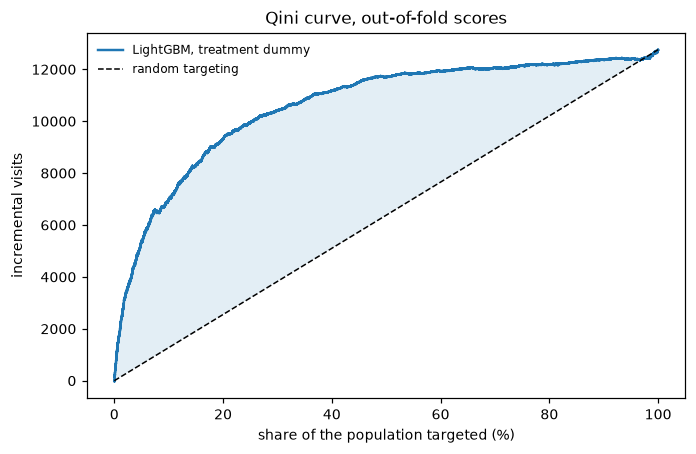

wrote ['ab_test.csv', 'balance.csv', 'cv_folds.csv', 'cv_summary.csv', 'deciles.csv', 'policy.csv', 'qini.png', 'quality.csv', 'rates.csv', 'slo.csv']

notebook runtime to this point: 9.8 minutes


In [20]:
OUT = "results"
os.makedirs(OUT, exist_ok=True)

tables = {"rates": (rates, True), "balance": (smd.round(4), True), "quality": (quality, False),
          "cv_folds": (folds.round(4), False), "cv_summary": (summary, True),
          "ab_test": (ab, False), "slo": (slo, False), "deciles": (deciles, True),
          "policy": (policy, False)}
for name, (frame, index) in tables.items():
    frame.to_csv(os.path.join(OUT, f"{name}.csv"), index=index)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
x, curve = qini_points(y_visit, oof_uplift, treat)
ax.plot(x * 100, curve, lw=1.6, label=winner)
ax.plot([0, 100], [0, curve[-1]], color="black", ls="--", lw=1, label="random targeting")
ax.fill_between(x * 100, curve, x * curve[-1], alpha=.12)
ax.set_xlabel("share of the population targeted (%)")
ax.set_ylabel("incremental visits")
ax.set_title("Qini curve, out-of-fold scores")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "qini.png"), dpi=220)
plt.show()

print("wrote", sorted(os.listdir(OUT)))
print(f"\nnotebook runtime to this point: {(time.time() - start) / 60:.1f} minutes")

## Findings

| Premise | Answer |
| --- | --- |
| Is this a randomised trial? | Yes. Every standardised difference is under 0.05, and the propensity AUC is 0.51 |
| Is the data clean? | Six rules of seven. 22,177 duplicate rows leave |
| Can a fold measure conversion? | No. 0.3% positives. The models rank on visits |
| Does the sophisticated model win? | No. The two-model approach comes last |
| Did the ad work? | Yes. Visits rise 1.09pp, conversions 0.12pp, both far above the detectable minimum |
| Does the ranking hold out? | Yes. The SLO passes in all five folds |
| Who is worth bidding on? | The top 10%. It carries 65% of the incremental conversions |

The naive reading of this campaign is that the ad lifts conversions by 58%, so
bid on everybody. That is true and useless.

Most of the lift sits in a tenth of the population. The other nine tenths spend
the budget on sales that were coming anyway.